In [19]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-
# @Time    : 2025/6/9 21:30
# @Author  : YWJ
# @FileName: scatterplot.ipython
# @Software: jupyter
import numpy as np
import pandas as pd
from matplotlib import colors  # 注意！为了调整“色盘”，需要导入colors
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns; sns.set()  # for plot styling
# import xlrd
%matplotlib inline
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
from matplotlib import rcParams
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap,LinearSegmentedColormap, Normalize
from sklearn.impute import SimpleImputer
from sklearn import datasets
from sklearn.manifold import TSNE
from matplotlib import font_manager
import matplotlib as mpl

In [4]:
with open("all_mgnify_species_level_cluster_genome_anno_genus_fin_crispr_amr_num_anno_rgi.txt") as f:
    amr_number=[]
    crispr_number=[]
    amr_abundence=[]
    crispr_abundence=[]
    amr_abundence_lg=[]
    genome_len=[]
    biome=[]
    genus=[]
    for i in f:
        i=i.strip().split("\t")
        crispr_number.append(int(i[1]))
        crispr_abundence.append(int(i[1])/int(i[6]))
        amr_number.append(int(i[11]))
        amr_abundence.append(int(i[11])/int(i[6]))
        genome_len.append(int(i[6]))
        biome.append(i[4])
        genus.append(i[9])
        if int(i[11])==0:
            amr_abundence_lg.append(float(-18))
        else:
            amr_abundence_lg.append(np.log10(int(i[11])/int(i[6])))
data=pd.DataFrame({"crispr_number":crispr_number,"amr_number":amr_number,"crispr_abundence":crispr_abundence,"amr_abundence":amr_abundence,"amr_abundence_lg":amr_abundence_lg,"genome_len":genome_len,"Biome":biome,"Genus":genus})
    # 分组并计算每组的总和，然后相除
grouped = data.groupby(["Biome", "Genus"]).sum()
# print(grouped)
grouped["crispr_per_mb"] = (grouped["crispr_number"] / grouped["genome_len"])*1000000
grouped["amr_per_mb"] = grouped["amr_number"] / grouped["genome_len"]*1000000
# grouped.to_csv("all_biome_genus_data_rgi_20250731_grouped.csv",index=True)
# 如果你只想保留这两个新计算的列：
result = grouped[["crispr_per_mb", "amr_per_mb"]].reset_index()
# crispr = result.pivot(index='Genus', columns='Biome', values='crispr_per_mb')
# amr = result.pivot(index='Genus', columns='Biome', values='amr_per_mb')
# print(result)

In [5]:
# 先构造适合热图的数据格式
crispr = result.pivot(index='Genus', columns='Biome', values='crispr_per_mb')
amr = result.pivot(index='Genus', columns='Biome', values='amr_per_mb')
# 保留每行中非空值数量 >= 2 的行
crispr_filtered = crispr.dropna(thresh=2)
amr_filtered = amr.dropna(thresh=2)
# 添加统计指标
crispr_filtered1=crispr_filtered.copy()
# print(crispr_filtered)
amr_filtered1=amr_filtered.copy()
crispr_filtered1["max"] = crispr_filtered.max(axis=1)
crispr_filtered1["min"] = crispr_filtered.min(axis=1)
crispr_filtered1["range"] = crispr_filtered1["max"] - crispr_filtered1["min"]
crispr_filtered1["mean"] = crispr_filtered.mean(skipna=True,axis=1)
crispr_filtered1["dispersion"] = crispr_filtered1["range"] / crispr_filtered1["mean"]
amr_filtered1["max"] = amr_filtered.max(axis=1)
amr_filtered1["min"] = amr_filtered.min(axis=1)
amr_filtered1["range"] = amr_filtered1["max"] - amr_filtered1["min"]
amr_filtered1["mean"] = amr_filtered.mean(axis=1, skipna=True)
amr_filtered1["dispersion"] = amr_filtered1["range"] / amr_filtered1["mean"]
# crispr_filtered1.to_csv("all_biome_genus_crispr_divergence20250731.csv")
# amr_filtered1.to_csv("all_biome_genus_amr_divergence20250731.csv")
# print(amr_filtered)
crispr_filtered1 = crispr_filtered1.fillna(0)
amr_filtered1 = amr_filtered1.fillna(0)
# 查看结果


# print(crispr_filtered1.head())

# print(crispr)
# print(amr)

In [6]:
# 找出两个 DataFrame 的共同 Genus
common_index = crispr_filtered1.index.intersection(amr_filtered1.index)

# 筛选出共同 Genus 的数据
crispr_common = crispr_filtered1.loc[common_index]
amr_common = amr_filtered1.loc[common_index]

# 添加前缀以避免列名冲突
crispr_common = crispr_common.add_prefix("CRISPR_")
amr_common = amr_common.add_prefix("AMR_")

# 横向拼接
combined = pd.concat([crispr_common, amr_common], axis=1)
combined1 = combined.fillna(0)
# combined.to_csv("all_biome_genus_crispr_amr_divergence.csv")
combined1['log_AMR_dispersion'] = combined1['AMR_dispersion'].apply(lambda x: np.log(x + 1) if x == 0 else np.log(x))
combined1['log_CRISPR_dispersion'] = combined1['CRISPR_dispersion'].apply(lambda x: np.log(x + 1) if x == 0 else np.log(x))
combined1['log_AMR_range'] = combined1['AMR_range'].apply(lambda x: np.log(x + 1) if x == 0 else np.log(x))
combined1['log_CRISPR_range'] = combined1['CRISPR_range'].apply(lambda x: np.log(x + 1) if x == 0 else np.log(x))
# combined1.to_csv("all_biome_genus_crispr_amr_divergence_log.csv")
# 查看结果
# print(combined1.head())


In [7]:
with open("proprity_resistance_genus_fin.txt") as f:
    priority_genus=[]
    for i in f:
        i=i.strip()
        priority_genus.append(i)
        

In [8]:
# color1=["#1F77B4","#FF7F0E","#2CA02C","#D62728","#9467BD","#E377C2","#BCBD23","#17BECF","#ffde02","#ee6b8b","#51755b","#FFB74D"]
color1=["#D62728","#1F77B4","#FF7F0E","#2CA02C","#9467BD","#E377C2","#BCBD23","#17BECF","#ffde02","#ee6b8b","#51755b","#FFB74D"]

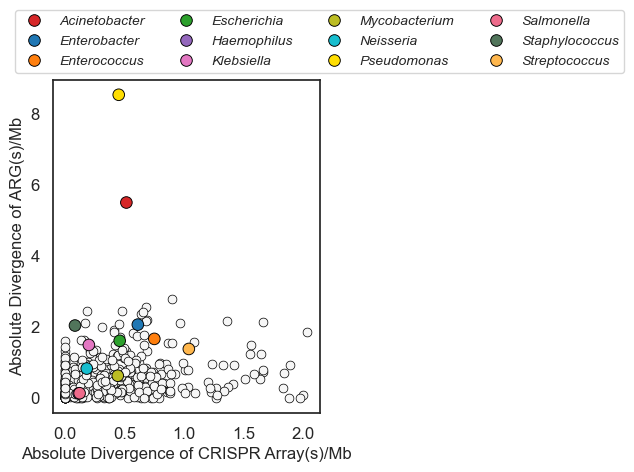

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
with open("proprity_resistance_genus_fin.txt") as f:
    priority_genus=[]
    for i in f:
        i=i.strip()
        priority_genus.append(i)
# 添加分组标签
combined1["Group"] = combined1.index.to_series().apply(
    lambda x: x if x in priority_genus else "Other"
)
# print(set(combined1["Group"]))
# 分别获取两类数据
acinetobacter_data = combined1[combined1["Group"] == "Acinetobacter"]
priority_data = combined1[combined1["Group"] != "Other"]
other_data = combined1[combined1["Group"] == "Other"]

# print(priority_data)
plt.figure(figsize=(6.5, 5))
sns.set_style("white")

config = {
    "font.family": 'Arial',
    "mathtext.fontset": 'stix'
}
plt.rcParams.update(config)

# 先绘制其他（灰色，底层）
sns.scatterplot(
    x="CRISPR_range", 
    y="AMR_range",
    data=other_data,
    color="#f6f6f6",
    edgecolor="black",
    s=40,
    alpha=1,
    zorder=1
)

# 再绘制 Acinetobacter（蓝色，顶层）
sns.scatterplot(
    x="CRISPR_range", 
    y="AMR_range",
    hue="Group",
    data=priority_data,
    palette=color1,
    edgecolor="black",
    s=70,
    alpha=1,
    zorder=2  # 更高 zorder 表示置于顶层
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Absolute Divergence of CRISPR Array(s)/Mb", fontsize=12)
plt.ylabel("Absolute Divergence of ARG(s)/Mb", fontsize=12)
# 获取图例句柄和标签
handles, labels = plt.gca().get_legend_handles_labels()
plt.rcParams['font.family'] = 'Arial'
# 重建图例，手动指定标签样式
# 指定 Arial 字体，并设置为 italic
arial_italic = font_manager.FontProperties(family='Arial', style='italic', size=10)

plt.legend(handles=handles, labels=labels, ncol=4,  fontsize=12,# 注意：不要加 $，不要 mathtext
           loc='upper center', bbox_to_anchor=(1.0, 1.23),
           prop=arial_italic)
# arial_font = font_manager.FontProperties(family="Arial", size=8)
# # plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left', prop=arial_font)
# plt.legend(handles=handles, labels=[f"${label}$" for label in labels], 
#            loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=8,prop=arial_font)
# plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left',fontsize=8)
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42

# plt.savefig('CRISPR_AMRs_rgi_biome_genus_absolute_scatter_cover_legend_20260513.png', bbox_inches='tight', dpi=800)
# plt.savefig('CRISPR_AMRs_rgi_biome_genus_absolute_scatter_cover_legend_20260513.pdf', bbox_inches='tight')
plt.show()

In [11]:
grouped_scatter = data.groupby(["Biome"]).sum()
# print(grouped)
grouped_scatter ["crispr_per_mb"] = (grouped_scatter ["crispr_number"] / grouped_scatter ["genome_len"])*1000000
grouped_scatter ["amr_per_mb"] = grouped_scatter ["amr_number"] / grouped_scatter ["genome_len"]*1000000

# 如果你只想保留这两个新计算的列：
result_scatter  = grouped_scatter [["crispr_per_mb", "amr_per_mb"]].reset_index()
print(result_scatter )

                 Biome  crispr_per_mb  amr_per_mb
0          chicken-gut       0.253009    1.582292
1            cow-rumen       0.160949    1.097144
2         honeybee-gut       0.463530    2.199449
3            human-gut       0.271157    1.423683
4           human-oral       0.483485    0.876466
5        human-vaginal       0.364833    1.053274
6               marine       0.066693    0.395666
7            mouse-gut       0.231596    1.582640
8   non-model-fish-gut       0.145403    1.439239
9              pig-gut       0.210857    1.263739
10         sheep-rumen       0.169774    1.027310
11     zebrafish-fecal       0.107965    0.844664


<Figure size 600x600 with 0 Axes>

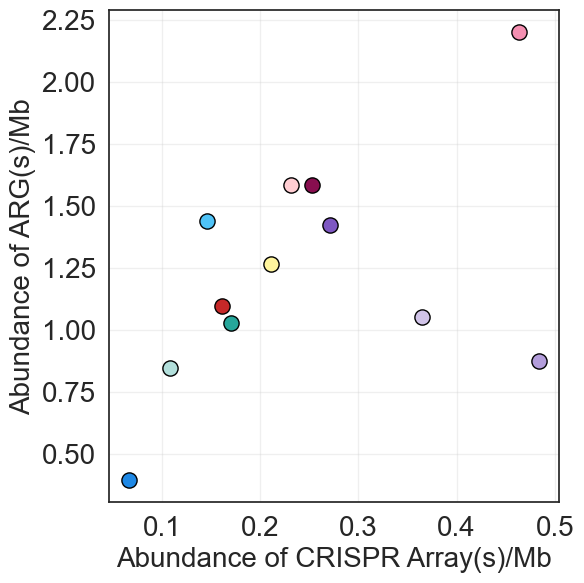

In [12]:
# Calculate median values for each biome
# Create the scatter plot
plt.figure(figsize=(6, 6))
sns.set_style("white")
config = {
    "font.family":'Arial',  # 设置字体类型
#     "font.size": 80,
    "mathtext.fontset":'stix'
}
color=["#880E4F","#C62828","#F48FB1","#7E57C2","#B39DDB","#D1C4E9","#1E88E5","#FFCDD2","#4FC3F7","#FFF59D","#26A69A","#B2DFDB"]
# Get unique biomes and assign colors
unique_biomes = result_scatter['Biome'].unique()
# colors = plt.cm.get_cmap('tab20', len(unique_biomes))

for i, biome in enumerate(unique_biomes):
    biome_data = result_scatter[result_scatter['Biome'] == biome]
    plt.scatter(biome_data['crispr_per_mb'], 
                biome_data['amr_per_mb'], 
                color=color[i],
                s=120,
                label=biome,
                edgecolor="black")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Abundance of CRISPR Array(s)/Mb', fontsize=20)
plt.ylabel('Abundance of ARG(s)/Mb', fontsize=20)
# plt.title('Median CRISPR vs AMR Numbers by Biome', fontsize=14)
plt.grid(True, alpha=0.3)

# Add legend (you might need to adjust its position)6
# plt.legend(bbox_to_anchor=(1.55, 1.01), loc='upper right',fontsize=12)
plt.tight_layout()
# plt.savefig('CRISPR_ARGs_biome_MAGs_20260512.png',bbox_inches='tight',dpi=800)
# plt.savefig('CRISPR_ARGs_biome_MAGs_20260512.pdf',bbox_inches='tight')
plt.show()

In [13]:
data_abundence=data.copy()
data_abundence["crispr_abundence"] = data_abundence ["crispr_abundence"]*1000000
data_abundence["amr_abundence"] = data_abundence ["amr_abundence"]*1000000
print(data_abundence)

       crispr_number  amr_number  crispr_abundence  amr_abundence  \
0                  0           9          0.000000       2.793541   
1                  0           4          0.000000       0.900697   
2                  0           2          0.000000       0.618385   
3                  0           5          0.000000       1.348709   
4                  0           9          0.000000       2.288603   
...              ...         ...               ...            ...   
29551              1           3          0.155879       0.467637   
29552              0           1          0.000000       0.350512   
29553              0           1          0.000000       0.216879   
29554              0           6          0.000000       1.347651   
29555              0           0          0.000000       0.000000   

       amr_abundence_lg  genome_len      Biome             Genus  
0             -5.553845     3221717  human-gut           Unknown  
1             -6.045421     4441003  

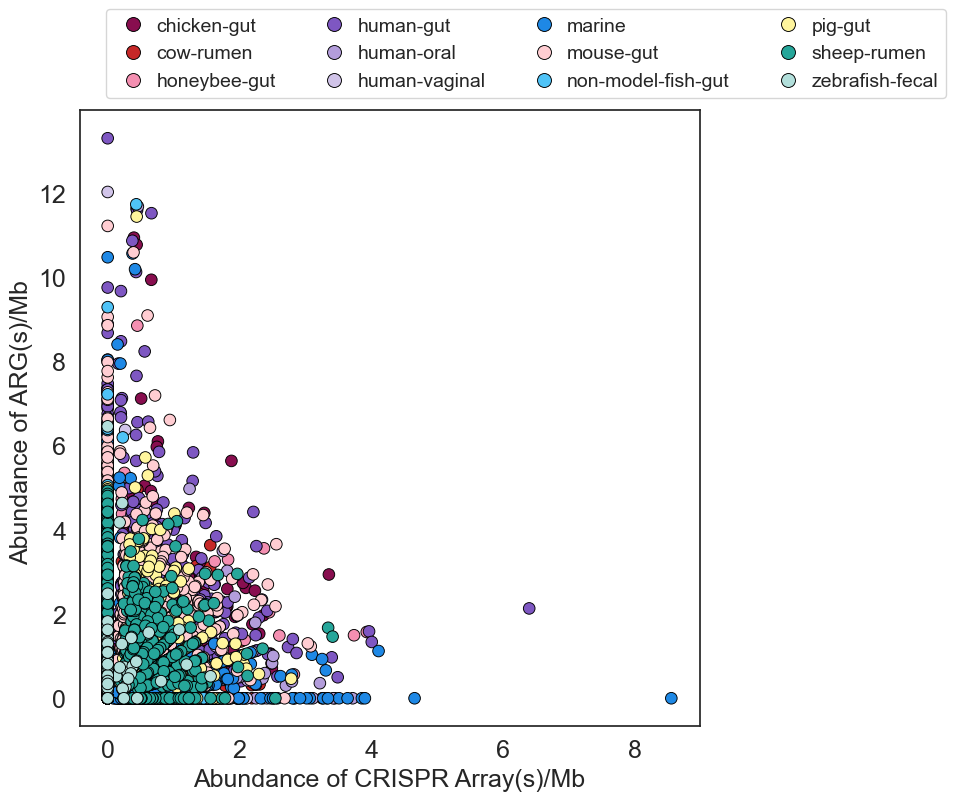

In [14]:
data_abundence=data.copy()
data_abundence["crispr_abundence"] = data_abundence ["crispr_abundence"]*1000000
data_abundence["amr_abundence"] = data_abundence ["amr_abundence"]*1000000
data_abundence = data_abundence.sort_values(by='Biome')

plt.figure(figsize=(8,8))
sns.set_style("white")
config = {
    "font.family":'Arial',  # 设置字体类型
#     "font.size": 80,
    "mathtext.fontset":'stix'
}
color=["#880E4F","#C62828","#F48FB1","#7E57C2","#B39DDB","#D1C4E9","#1E88E5","#FFCDD2","#4FC3F7","#FFF59D","#26A69A","#B2DFDB"]
sns.scatterplot(
    x="crispr_abundence", y="amr_abundence",
    hue="Biome",
    palette=color,
    data=data_abundence,
    legend="full",
    alpha=1,
    s=70,
    zorder=1,
    edgecolor="black"
)
# # 添加每个 Biome 的拟合曲线
# for index_1,biome in enumerate(data_sorted2["Biome"].unique()):
#     sub_data = data_sorted2[data_sorted2["Biome"] == biome]
#     sns.regplot(
#         x="Crispr abundence", y="AMR abundence",
#         data=sub_data,
#         scatter=False,
#         color=color[index_1],  # 确保颜色一致
#         line_kws={"linewidth": 2},
#         ci=20
#     )
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Abundance of CRISPR Array(s)/Mb",fontsize=18)
plt.ylabel("Abundance of ARG(s)/Mb ",fontsize=18)
plt.legend(loc='upper center',ncol=4, fontsize=14, handletextpad=0.2,markerscale=1.2,bbox_to_anchor=(0.72, 1.18))  # Adjust as needed
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('CRISPR_AMRs_biome_abundance_scatter_20260512_legend.png',bbox_inches='tight',dpi=800)
# plt.savefig('CRISPR_AMRs_biome_abundance_scatter_20260512_legend.pdf',bbox_inches='tight')
plt.show()

In [15]:
with open("all_mgnify_species_level_cluster_genome_anno_genus_fin_crispr_amr_num_anno_rgi.txt") as f:
    amr_number=[]
    crispr_number=[]
    amr_abundence=[]
    crispr_abundence=[]
    crispr_abundence_lg=[]
    amr_abundence_lg=[]
    genome_len=[]
    biome=[]
    genus=[]
    for i in f:
        i=i.strip().split("\t")
        crispr_number.append(int(i[1]))
        crispr_abundence.append(int(i[1])/int(i[6]))
        if int(i[1])==0:
            crispr_abundence_lg.append(float(-18))
        else:
            crispr_abundence_lg.append(np.log10(int(i[1])/int(i[6])))
        amr_number.append(int(i[11]))
        amr_abundence.append(int(i[11])/int(i[6]))
        genome_len.append(int(i[6]))
        biome.append(i[4])
        genus.append(i[9])
        if int(i[11])==0:
            amr_abundence_lg.append(float(-18))
        else:
            amr_abundence_lg.append(np.log10(int(i[11])/int(i[6])))
data=pd.DataFrame({"crispr_number":crispr_number,"amr_number":amr_number,"crispr_abundence":crispr_abundence,"amr_abundence":amr_abundence,"amr_abundence_lg":amr_abundence_lg,"genome_len":genome_len,"Biome":biome,"Genus":genus})
    # 分组并计算每组的总和，然后相除
grouped = data.groupby(["Biome", "Genus"]).sum()
# print(grouped)
grouped["crispr_per_mb"] = (grouped["crispr_number"] / grouped["genome_len"])*1000000
grouped["amr_per_mb"] = (grouped["amr_number"] / grouped["genome_len"])*1000000
grouped["crispr_per_mb_lg"] = np.log10((grouped["crispr_number"] / grouped["genome_len"])*1000000)
grouped["amr_per_mb_lg"] = np.log10((grouped["amr_number"] / grouped["genome_len"])*1000000)
grouped.to_csv("all_biome_genus_data_rgi_20250731_grouped.csv",index=True)
# 如果你只想保留这两个新计算的列：
result = grouped[["crispr_per_mb", "amr_per_mb","crispr_per_mb_lg","amr_per_mb_lg"]].reset_index()
# crispr = result.pivot(index='Genus', columns='Biome', values='crispr_per_mb')
# amr = result.pivot(index='Genus', columns='Biome', values='amr_per_mb')
print(result)

                Biome              Genus  crispr_per_mb  amr_per_mb  \
0         chicken-gut      Acetatifactor       0.683686    3.076585   
1         chicken-gut      Acinetobacter       0.200394    0.868376   
2         chicken-gut      Acutalibacter       0.295908    3.787621   
3         chicken-gut          Adamsella       0.677864    2.259547   
4         chicken-gut      Aeriscardovia       1.278192    0.639096   
...               ...                ...            ...         ...   
2674  zebrafish-fecal         Roseiarcus       0.000000    0.177815   
2675  zebrafish-fecal  Sediminibacterium       0.000000    0.324122   
2676  zebrafish-fecal         Shewanella       0.434205    0.868410   
2677  zebrafish-fecal   Stenotrophomonas       0.000000    1.334339   
2678  zebrafish-fecal            Unknown       0.147243    0.625784   

      crispr_per_mb_lg  amr_per_mb_lg  
0            -0.165144       0.488069  
1            -0.698114      -0.061292  
2            -0.528843     

D:\program\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
D:\program\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
with open("proprity_resistance_genus_fin.txt") as f:
    priority_genus=[]
    for i in f:
        i=i.strip()
        priority_genus.append(i)
color1=["#D62728","#1F77B4","#FF7F0E","#2CA02C","#9467BD","#E377C2","#BCBD23","#17BECF","#ffde02","#ee6b8b","#51755b","#FFB74D"]

In [17]:
# 先构造适合热图的数据格式
crispr = result.pivot(index='Genus', columns='Biome', values='crispr_per_mb').fillna(0) 
amr = result.pivot(index='Genus', columns='Biome', values='amr_per_mb').fillna(0) 

# 为区分 CRISPR 和 AMR，给列加上前缀
crispr.columns = [f'{col}_CRISPR' for col in crispr.columns]
amr.columns = [f'{col}_AMR' for col in amr.columns]

# 合并为一个 DataFrame
heatmap_data = pd.concat([crispr, amr], axis=1)

# 按列名排序（让相同 biome 的 CRISPR 和 AMR 挨在一起）
# heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)


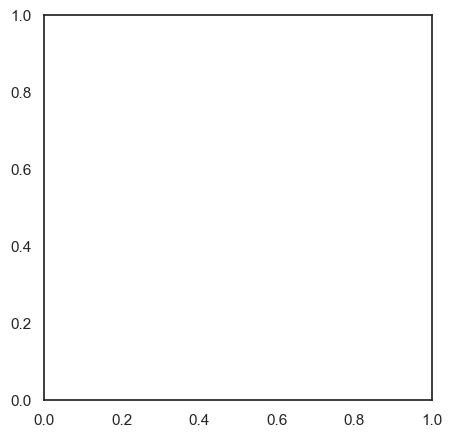

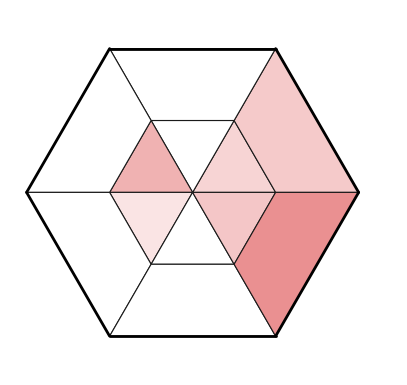

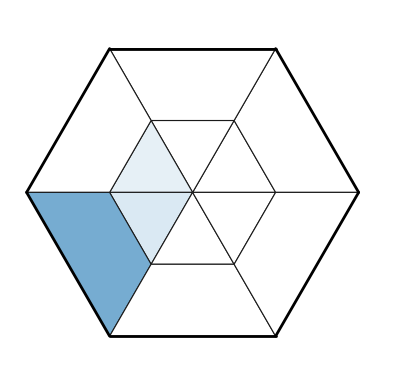

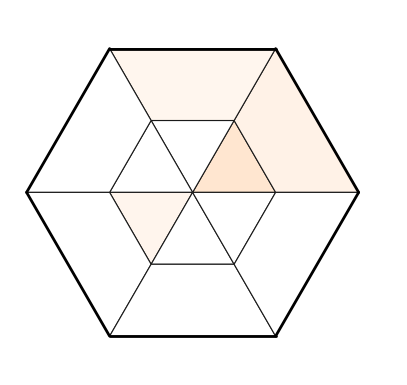

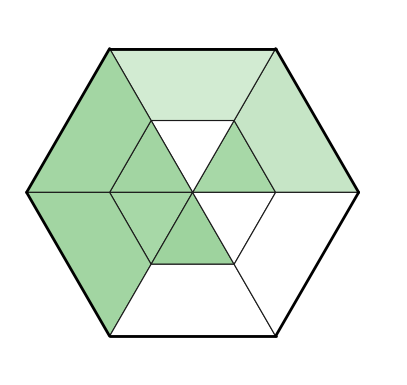

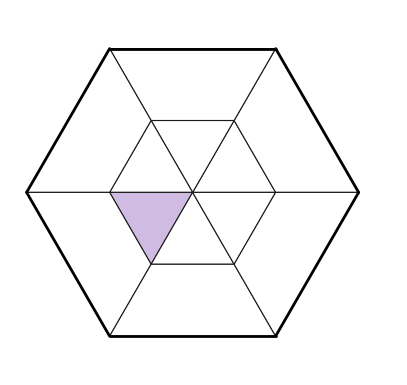

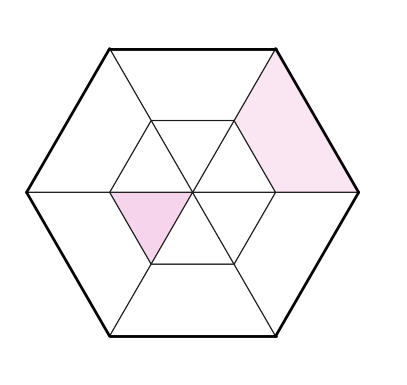

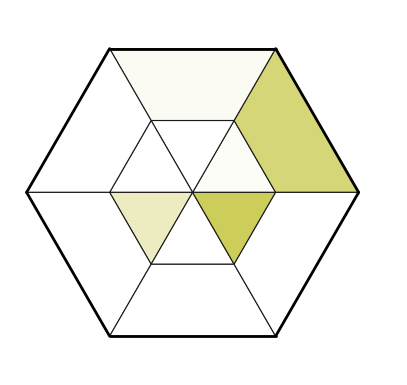

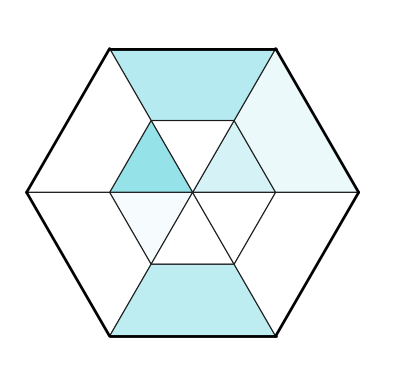

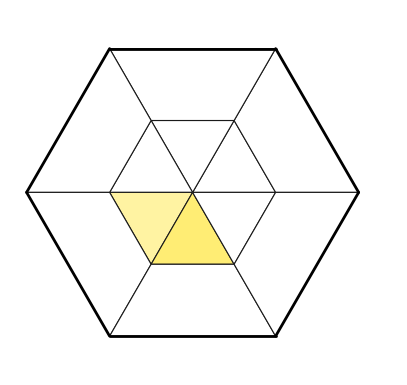

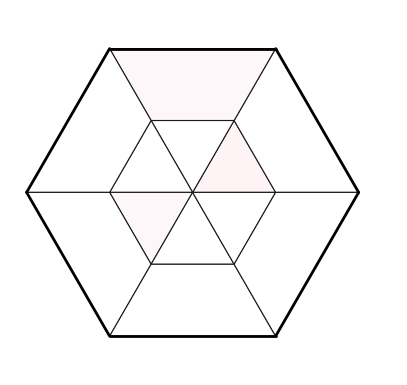

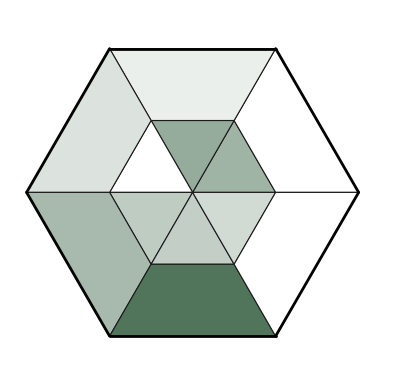

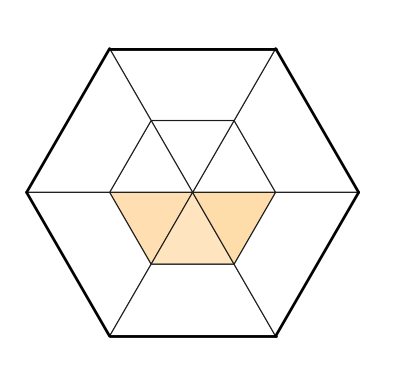

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib import cm, colors

# ---------- 配置 ----------
n_sides = 6
angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)  # 6 个角
r_inner = 1.0    # 内六边形顶点半径
r_outer = 2.0    # 外六边形顶点半径

# 示例数据：前6个给内层，后6个给外层 (共12个)
# 你把这里替换为真实数值即可
for n, genus in enumerate(priority_genus):
    crispr_data=crispr.loc[genus].values
    biomes_name=[i.split("_")[0] for i in crispr.loc["Acinetobacter"].index]
    data = np.array(crispr_data) # 外层 6 个
    outer_polys = []  # 保存外层六个 polygon
    # cmap = cm.get_cmap("RdBu_r")   # 你可以改成其他 colormap
    # norm = colors.Normalize(vmin=-1, vmax=1)  # 根据数值区间调整 vmin/vmax
    
    # ---------- 计算顶点 ----------
    center = (0.0, 0.0)
    inner_verts = [(r_inner*np.cos(a), r_inner*np.sin(a)) for a in angles]
    outer_verts = [(r_outer*np.cos(a), r_outer*np.sin(a)) for a in angles]
    
    fig,ax = plt.subplots(figsize=(5,5), facecolor='none')
    config = {
        "font.family":'Arial',  # 设置字体类型
    #     "font.size": 80,
        "mathtext.fontset":'stix'
    }
    # 自定义颜色渐变（这里仅蓝色为例）
    custom_gradient = LinearSegmentedColormap.from_list("custom_gradient", ["#ffffff", color1[n]])
    norm = Normalize(vmin=0, vmax=1)
    # norm = Normalize(vmin=crispr.min().min(), vmax=crispr.max().max())   # 数据范围要和 data 对应
    # 构造列颜色（条带）
    # col_colors = pd.Series(heatmap_data.columns).apply(lambda x: '#87CEFA' if 'CRISPR' in x else '#CD5C5C')
    # col_colors.index = heatmap_data.columns
    ax.set_aspect('equal')
    ax.axis('off')
    
    # ---------- 画内层（6 个三角形，从中心到内六边形边） ----------
    for j in range(n_sides):
        v0 = center
        v1 = inner_verts[j]
        v2 = inner_verts[(j+1) % n_sides]
        poly = Polygon([v0, v1, v2], closed=True,
                       facecolor=custom_gradient(norm(data[j])),
                       edgecolor='k', linewidth=0.8)
        ax.add_patch(poly)
        # 标签（放在三角重心附近）
        cx = (v0[0] + v1[0] + v2[0]) / 3.0
        cy = (v0[1] + v1[1] + v2[1]) / 3.0
        # ax.text(cx, cy, f"A{j+1}", ha='center', va='center', fontsize=9)
    
    # ---------- 画外层（6 个四边形带） ----------
    for j in range(n_sides):
        v1 = inner_verts[j]
        v2 = inner_verts[(j+1) % n_sides]
        v3 = outer_verts[(j+1) % n_sides]
        v4 = outer_verts[j]
        poly = Polygon([v1, v2, v3, v4], closed=True,
                       facecolor=custom_gradient(norm(data[n_sides + j])),
                       edgecolor='k', linewidth=0.8)
        ax.add_patch(poly)
        outer_polys.append([v4, v3])  # 保存最外圈的边
        # 标签（放在四边形中心附近）
        cx = (v1[0] + v2[0] + v3[0] + v4[0]) / 4.0
        cy = (v1[1] + v2[1] + v3[1] + v4[1]) / 4.0
        # ax.text(cx, cy, f"B{j+1}", ha='center', va='center', fontsize=9)
    # # ---------- 最外圈描白线 ----------
    for edge in outer_polys:
        xs, ys = zip(*edge)
        ax.plot(xs, ys, color="black",linewidth=2.0)
        
    # # ---------- colorbar ----------
    # sm = cm.ScalarMappable(cmap=custom_gradient, norm=norm)
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    # # ax_cbar_crispr.set_title("CRISPR Array(s) abundance", fontsize=10)
    # cbar.set_label('CRISPR Array(s) abundance', fontsize=10)
    # cbar.outline.set_visible(False)  # 去掉外框
    # cbar.ax.yaxis.set_ticks([])      # 去掉刻度
    # cbar.ax.yaxis.label.set_visible(False)  # 保留标签
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.04)  # 位置和宽度
    
    # 在 cax 上隐藏色条
    cax.axis('off')  # 隐藏条带和刻度

    # ---------- 视图限与显示 ----------
    pad = 0.2
    lim = r_outer + pad
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    # plt.title(f"${genus}$" )
    mpl.rcParams['pdf.fonttype'] = 42
    # plt.savefig('metagenome_CRISPR_AMRs_'+str(genus)+'_absolute_priority_crispr_20250911_edge1.png', bbox_inches='tight', dpi=800)
    # plt.savefig('metagenome_CRISPR_AMRs_'+str(genus)+'_absolute_priority_crispr_20250911_edge1.pdf', bbox_inches='tight')
    plt.show()


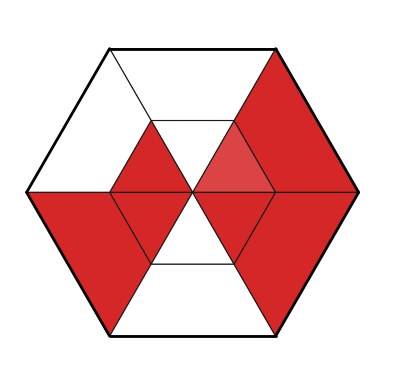

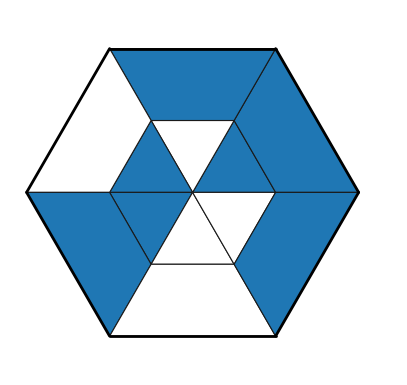

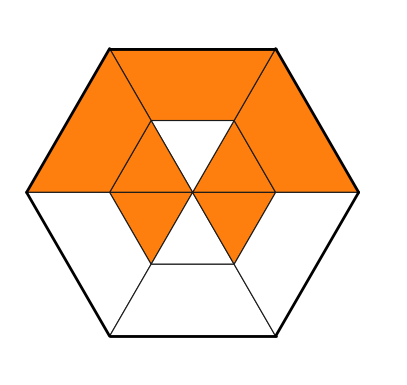

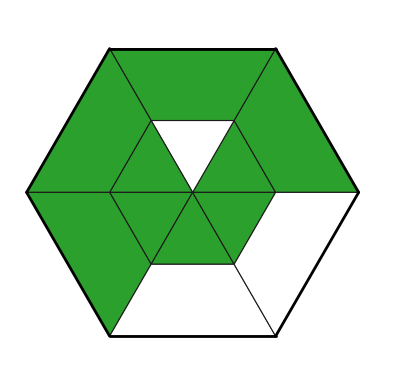

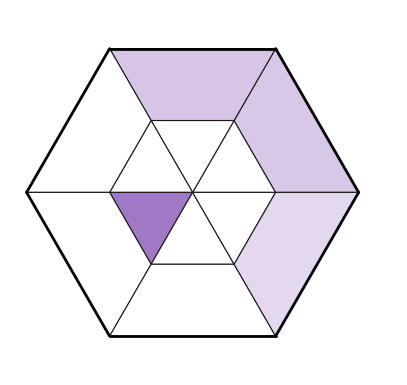

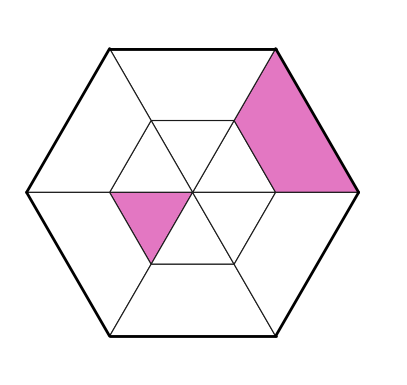

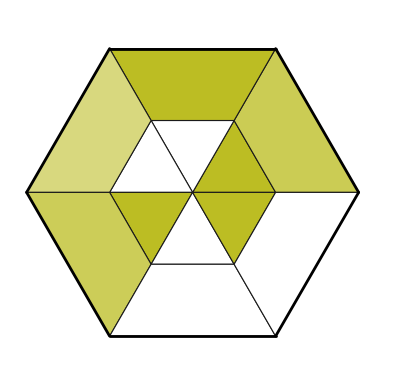

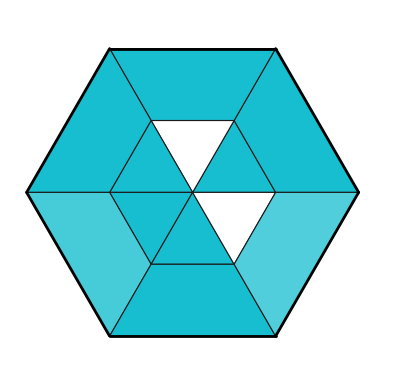

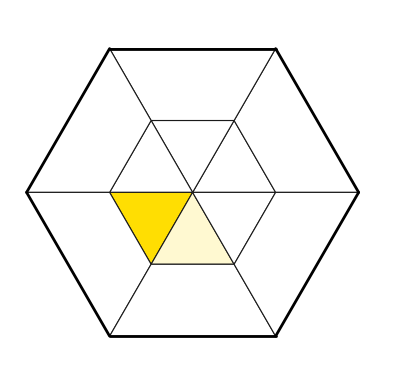

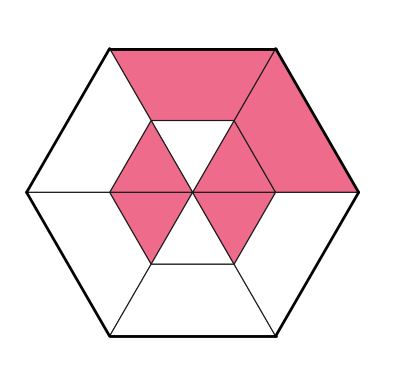

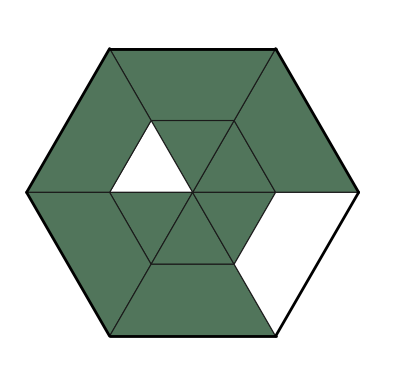

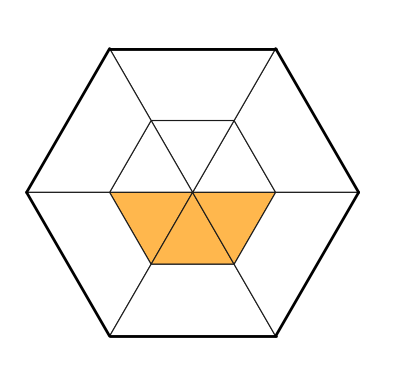

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib import cm, colors

# ---------- 配置 ----------
n_sides = 6
angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)  # 6 个角
r_inner = 1.0    # 内六边形顶点半径
r_outer = 2.0    # 外六边形顶点半径

# 示例数据：前6个给内层，后6个给外层 (共12个)
# 你把这里替换为真实数值即可
for n, genus in enumerate(priority_genus):
    amr_data=amr.loc[genus].values
    biomes_name=[i.split("_")[0] for i in amr.loc["Acinetobacter"].index]
    data = np.array(amr_data) # 外层 6 个
    outer_polys = []  # 保存外层六个 polygon
    # cmap = cm.get_cmap("RdBu_r")   # 你可以改成其他 colormap
    # norm = colors.Normalize(vmin=-1, vmax=1)  # 根据数值区间调整 vmin/vmax
    
    # ---------- 计算顶点 ----------
    center = (0.0, 0.0)
    inner_verts = [(r_inner*np.cos(a), r_inner*np.sin(a)) for a in angles]
    outer_verts = [(r_outer*np.cos(a), r_outer*np.sin(a)) for a in angles]
    
    fig,ax = plt.subplots(figsize=(5,5), facecolor='none')
    config = {
        "font.family":'Arial',  # 设置字体类型
    #     "font.size": 80,
        "mathtext.fontset":'stix'
    }
    # 自定义颜色渐变（这里仅蓝色为例）
    custom_gradient = LinearSegmentedColormap.from_list("custom_gradient", ["#ffffff", color1[n]])
    norm = Normalize(vmin=0, vmax=1)
    # norm = Normalize(vmin=crispr.min().min(), vmax=crispr.max().max())   # 数据范围要和 data 对应
    # 构造列颜色（条带）
    # col_colors = pd.Series(heatmap_data.columns).apply(lambda x: '#87CEFA' if 'CRISPR' in x else '#CD5C5C')
    # col_colors.index = heatmap_data.columns
    ax.set_aspect('equal')
    ax.axis('off')
    
    # ---------- 画内层（6 个三角形，从中心到内六边形边） ----------
    for j in range(n_sides):
        v0 = center
        v1 = inner_verts[j]
        v2 = inner_verts[(j+1) % n_sides]
        poly = Polygon([v0, v1, v2], closed=True,
                       facecolor=custom_gradient(norm(data[j])),
                       edgecolor='k', linewidth=0.8)
        ax.add_patch(poly)
        # 标签（放在三角重心附近）
        cx = (v0[0] + v1[0] + v2[0]) / 3.0
        cy = (v0[1] + v1[1] + v2[1]) / 3.0
        # ax.text(cx, cy, f"A{j+1}", ha='center', va='center', fontsize=9)
    
    # ---------- 画外层（6 个四边形带） ----------
    for j in range(n_sides):
        v1 = inner_verts[j]
        v2 = inner_verts[(j+1) % n_sides]
        v3 = outer_verts[(j+1) % n_sides]
        v4 = outer_verts[j]
        poly = Polygon([v1, v2, v3, v4], closed=True,
                       facecolor=custom_gradient(norm(data[n_sides + j])),
                       edgecolor='k', linewidth=0.8)
        ax.add_patch(poly)
        outer_polys.append([v4, v3])  # 保存最外圈的边
        # 标签（放在四边形中心附近）
        cx = (v1[0] + v2[0] + v3[0] + v4[0]) / 4.0
        cy = (v1[1] + v2[1] + v3[1] + v4[1]) / 4.0
        # ax.text(cx, cy, f"B{j+1}", ha='center', va='center', fontsize=9)
    # # ---------- 最外圈描白线 ----------
    for edge in outer_polys:
        xs, ys = zip(*edge)
        ax.plot(xs, ys, color="black",linewidth=2.0)
        
    # # ---------- colorbar ----------
    # sm = cm.ScalarMappable(cmap=custom_gradient, norm=norm)
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    # # ax_cbar_crispr.set_title("CRISPR Array(s) abundance", fontsize=10)
    # cbar.set_label('CRISPR Array(s) abundance', fontsize=10)
    # cbar.outline.set_visible(False)  # 去掉外框
    # cbar.ax.yaxis.set_ticks([])      # 去掉刻度
    # cbar.ax.yaxis.label.set_visible(False)  # 保留标签
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.04)  # 位置和宽度
    
    # 在 cax 上隐藏色条
    cax.axis('off')  # 隐藏条带和刻度

    # ---------- 视图限与显示 ----------
    pad = 0.2
    lim = r_outer + pad
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    # plt.title(f"${genus}$" )
    mpl.rcParams['pdf.fonttype'] = 42
    # plt.savefig('metagenome_CRISPR_AMRs_'+str(genus)+'_absolute_priority_ARG_20250912_edge1.png', bbox_inches='tight', dpi=800)
    # plt.savefig('metagenome_CRISPR_AMRs_'+str(genus)+'_absolute_priority_ARG_20250912_edge1.pdf', bbox_inches='tight')
    plt.show()


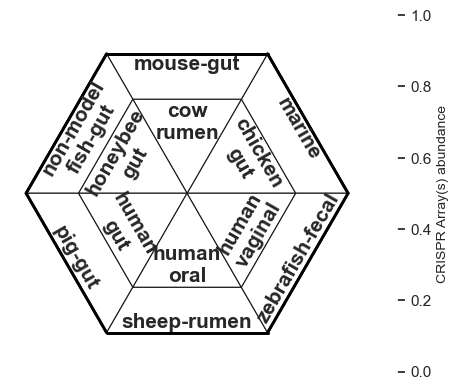

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---------- 配置 ----------
n_sides = 6
angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)  # 六边形角度
r_inner = 1.0    # 内层半径
r_outer = 2.0    # 外层半径

# 示例数据（12个值）
data = np.linspace(0, 1, 12)  # 换成你自己的数值

# ---------- 自定义渐变 ----------
custom_gradient = LinearSegmentedColormap.from_list(
    "custom_gradient", ["#ffffff", "#ffffff"]
)
norm = Normalize(vmin=0, vmax=1)   # 数据范围要和 data 对应

# ---------- 计算顶点 ----------
center = (0.0, 0.0)
inner_offset = 0.35  # 控制内圈往外推的距离
# inner_verts = [(r_inner*np.cos(a), r_inner*np.sin(a)) for a in angles]
inner_verts = [( (r_inner+inner_offset)*np.cos(a), 
                 (r_inner+inner_offset)*np.sin(a)) for a in angles]
outer_verts = [(r_outer*np.cos(a), r_outer*np.sin(a)) for a in angles]

fig, ax = plt.subplots(figsize=(5,5), facecolor='none')
ax.set_aspect('equal')
ax.axis('off')
offset = -0.05  # 调整偏移大小
# ---------- 内层 ----------
for j in range(n_sides):
    v0 = center
    v1 = inner_verts[j]
    v2 = inner_verts[(j+1) % n_sides]
    poly = Polygon([v0, v1, v2], closed=True,
                   facecolor=custom_gradient(norm(data[j])),
                   edgecolor='k', linewidth=0.8)
    ax.add_patch(poly)
    # 计算中心点
    cx = (v0[0] + v1[0] + v2[0]) / 3.0
    cy = (v0[1] + v1[1] + v2[1]) / 3.0

   # 底边方向向量
    dx = v2[0] - v1[0]
    dy = v2[1] - v1[1]
    angle = np.degrees(np.arctan2(dy, dx))

    # 翻转左半边文字
    if -90 > angle or angle > 90:
        angle += 180
    # 计算法向量，向外偏移
    nx, ny = -dy, dx
    length = np.hypot(nx, ny)
    nx, ny = nx/length, ny/length
    cx += nx * (offset-0.06)
    cy += ny * (offset-0.06)

    ax.text(cx, cy, "\n".join(biomes_name[j].split("-")), ha='center', va='center',
            rotation=angle, rotation_mode='anchor', fontsize=15,fontweight='bold')
# ---------- 外层 ----------
for j in range(n_sides):
    v1 = inner_verts[j]
    v2 = inner_verts[(j+1) % n_sides]
    v3 = outer_verts[(j+1) % n_sides]
    v4 = outer_verts[j]
    poly = Polygon([v1, v2, v3, v4], closed=True,
                   facecolor=custom_gradient(norm(data[n_sides + j])),
                   edgecolor='k', linewidth=0.8)
    ax.add_patch(poly)
    cx = (v1[0] + v2[0] + v3[0] + v4[0]) / 4.0
    cy = (v1[1] + v2[1] + v3[1] + v4[1]) / 4.0
    # 上边方向向量 v4 -> v3
    dx = v3[0] - v4[0]
    dy = v3[1] - v4[1]
    angle = np.degrees(np.arctan2(dy, dx))

    # 翻转左半边文字
    if -90 > angle or angle > 90:
        angle += 180

    
   # 法向量偏移
    nx, ny = -dy, dx
    length = np.hypot(nx, ny)
    nx, ny = nx/length, ny/length
    
    if biomes_name[6+j]=="non-model-fish-gut":
        biomes_name1=biomes_name[6+j].split("-fish")[0]+"\n"+"fish"+biomes_name[6+j].split("-fish")[1]
        cx += nx * (offset)
        cy += ny * (offset)
    else:
        biomes_name1=biomes_name[6+j]
        cx += nx * (offset-0.1)
        cy += ny * (offset-0.1)
    ax.text(cx, cy, biomes_name1, ha='center', va='center',
            rotation=angle, rotation_mode='anchor', fontsize=15,fontweight='bold')
    outer_polys.append([v4, v3])  # 保存最外圈的边
# # ---------- 最外圈描白线 ----------
for edge in outer_polys:
    xs, ys = zip(*edge)
    ax.plot(xs, ys, color="black",linewidth=2.0)
# ---------- colorbar ----------
sm = cm.ScalarMappable(cmap=custom_gradient, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
# ax_cbar_crispr.set_title("CRISPR Array(s) abundance", fontsize=10)
cbar.set_label('CRISPR Array(s) abundance', fontsize=10)
# cbar.outline.set_visible(False)  # 去掉外框
# cbar.ax.yaxis.set_ticks([])      # 去掉刻度
# cbar.ax.yaxis.label.set_visible(False)  # 保留标签
# 在 cax 上隐藏色条
cax.axis('off')  # 隐藏条带和刻度
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('metagenome_CRISPR_AMRs_genus_absolute_priority_crispr_legend_20250916.png', bbox_inches='tight', dpi=800)
# plt.savefig('metagenome_CRISPR_AMRs_genus_absolute_priority_crispr_legend_20250916.pdf', bbox_inches='tight')
plt.show()
